In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
def create_ts_data(data, window_size=5, target_col="OT"):
    df = data.copy()

    all_cols = [col for col in df.columns if col != "date"]
    new_columns = {}

    for i in range(1, window_size):
        for col in all_cols:
            new_columns["{}_lag_{}".format(col, i)] = df[col].shift(i)

    new_columns["target"] = df[target_col].shift(-1)

    new_cols_df = pd.DataFrame(new_columns, index=df.index)
    df = pd.concat([df, new_cols_df], axis=1)
    df = df.dropna()

    return df

In [19]:

data = pd.read_csv("./ETT-small/ETTh1.csv")
data["date"] = pd.to_datetime(data["date"])

window_size = 5
data = create_ts_data(data, window_size=window_size, target_col="OT")

# Tách biến đặc trưng X và biến mục tiêu Y
x = data.drop(["date", "target"], axis=1)
y = data["target"]

print(f"Kích thước tập dữ liệu đầu vào X: {x.shape}")
print(f"Kích thước tập nhãn mục tiêu Y: {y.shape}")

Kích thước tập dữ liệu đầu vào X: (17415, 35)
Kích thước tập nhãn mục tiêu Y: (17415,)


5 dong dau cua data sau create_ts_data:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,HUFL_lag_1,HULL_lag_1,...,LULL_lag_3,OT_lag_3,HUFL_lag_4,HULL_lag_4,MUFL_lag_4,MULL_lag_4,LUFL_lag_4,LULL_lag_4,OT_lag_4,target
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000,5.090,1.942,...,1.371,27.787001,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,21.174000
5,2016-07-01 05:00:00,5.626,2.143,1.528,0.533,4.051,1.371,21.174000,5.358,1.942,...,1.218,27.787001,5.693,2.076,1.492,0.426,4.142,1.371,27.787001,22.792000
6,2016-07-01 06:00:00,7.167,2.947,2.132,0.782,5.026,1.858,22.792000,5.626,2.143,...,1.279,25.044001,5.157,1.741,1.279,0.355,3.777,1.218,27.787001,23.143999
7,2016-07-01 07:00:00,7.435,3.282,2.310,1.031,5.087,2.224,23.143999,7.167,2.947,...,1.279,21.948000,5.090,1.942,1.279,0.391,3.807,1.279,25.044001,21.667000
8,2016-07-01 08:00:00,5.559,3.014,2.452,1.173,2.955,1.432,21.667000,7.435,3.282,...,1.371,21.174000,5.358,1.942,1.492,0.462,3.868,1.279,21.948000,17.445999


/tmp/ipykernel_206308/1870619421.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


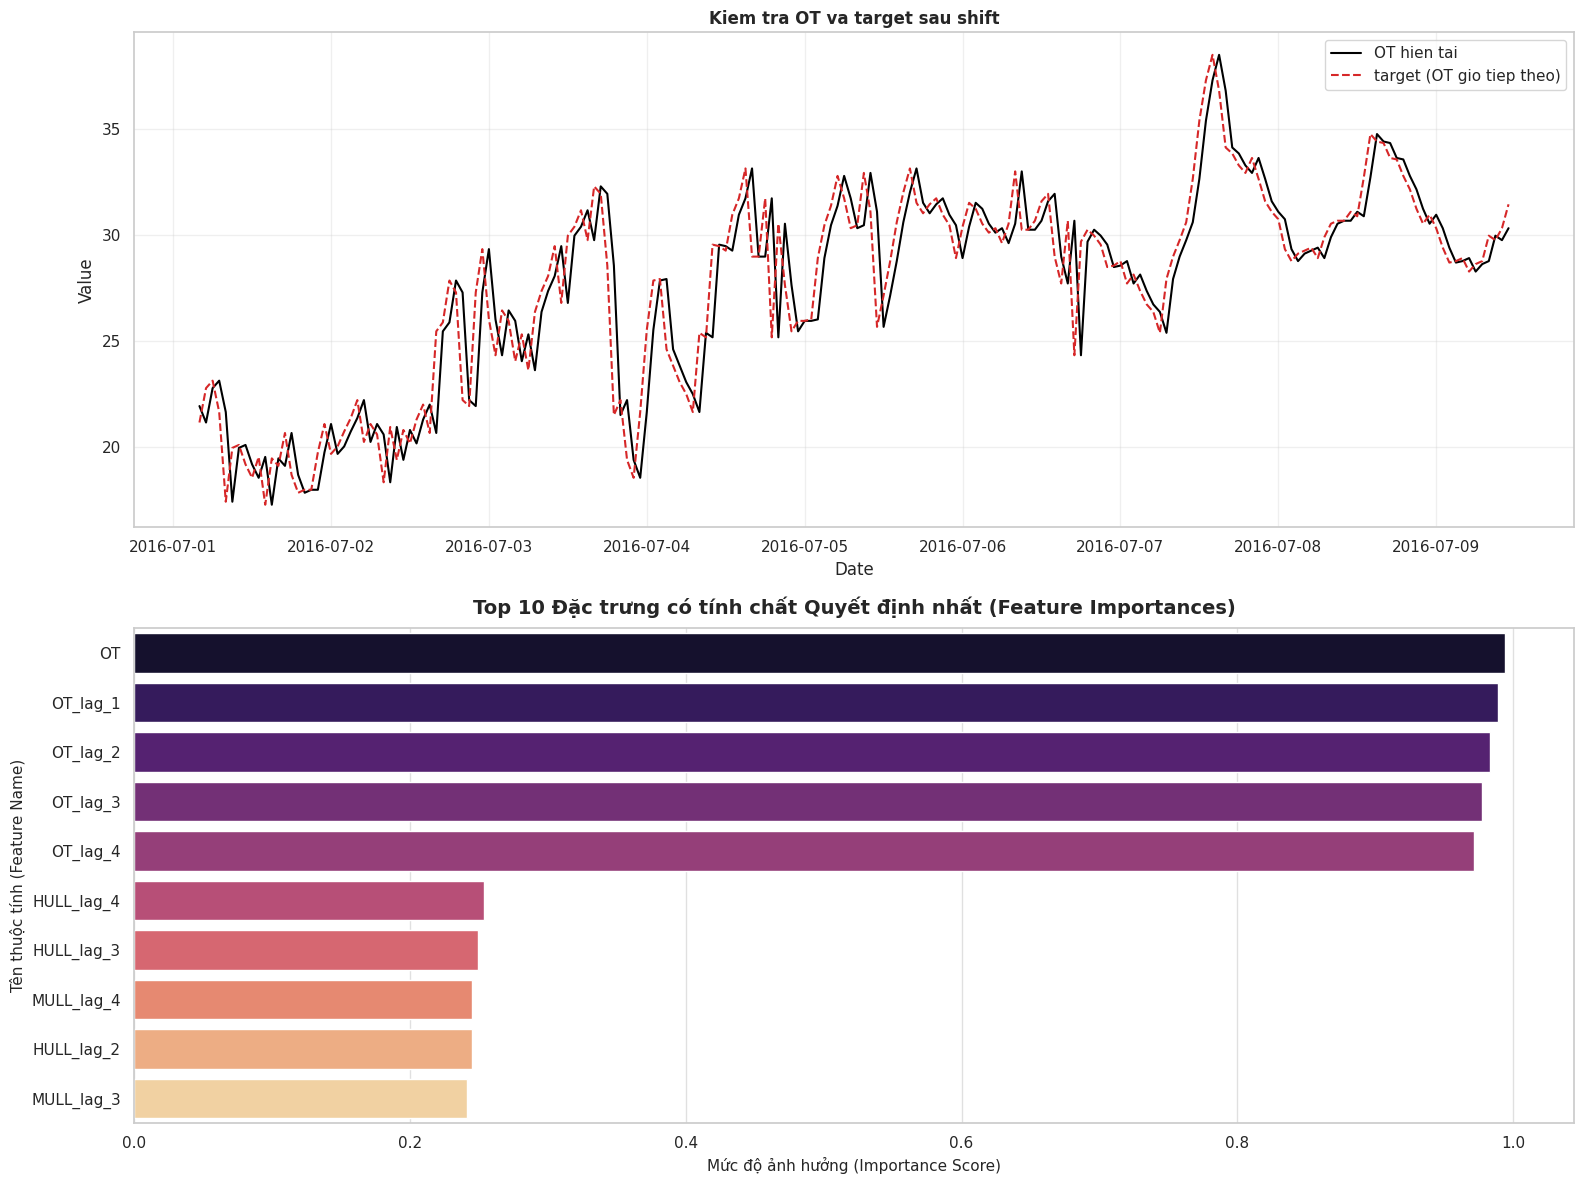

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

print("5 dong dau cua data sau create_ts_data:")
display(data.head())

# 1. Giữ nguyên phần vẽ chuỗi thời gian 200 điểm đầu ở phía trên
plot_df = data[["date", "OT", "target"]].head(200).copy()

# Khởi tạo Grid: Tầng 1 là chuỗi thời gian, Tầng 2 là Top 10 Feature Importances
fig = plt.figure(figsize=(16, 12)) # Kích thước rộng rãi cho cả 2 tầng
gs = fig.add_gridspec(2, 4)

# ================= TẦNG 1: CHUỖI THỜI GIAN (Chiếm hết hàng 0) =================
ax_line = fig.add_subplot(gs[0, :])
ax_line.plot(plot_df["date"], plot_df["OT"],
             label="OT hien tai", color="black", linewidth=1.5)
ax_line.plot(plot_df["date"], plot_df["target"],
             label="target (OT gio tiep theo)", linestyle="--", color="tab:red")
ax_line.set_title("Kiem tra OT va target sau shift",
                  fontsize=12, fontweight='bold')
ax_line.set_xlabel("Date")
ax_line.set_ylabel("Value")
ax_line.legend()
ax_line.grid(True, alpha=0.3)


# ================= TẦNG 2: FEATURE IMPORTANCE (Chiếm hết hàng 1) =================
ax_imp = fig.add_subplot(gs[1, :])

# Thiết kế style giống như ảnh bạn gửi (Nền trắng, có lưới dọc)
sns.set_theme(style="whitegrid") 

# Tạo feature_imp_df trực tiếp từ data để tránh lỗi "feature_imp_df is not defined"
feature_imp_df = (
    data.drop(columns=["date"], errors="ignore")
        .corr(numeric_only=True)["target"]
        .drop("target", errors="ignore")
        .abs()
        .sort_values(ascending=False)
        .reset_index()
)
feature_imp_df.columns = ["feature", "importance"]

# Vẽ biểu đồ với palette 'magma' (hoặc bạn có thể đổi thành 'flare' nếu muốn sáng hơn một chút)
sns.barplot(
    x="importance", 
    y="feature",
    data=feature_imp_df.head(10), # Lấy top 10 đặc trưng
    ax=ax_imp, 
    palette="magma"
)

# Cấu hình tiêu đề và nhãn theo style ảnh mẫu
ax_imp.set_title("Top 10 Đặc trưng có tính chất Quyết định nhất (Feature Importances)", 
                 fontsize=14, fontweight='bold', pad=10)
ax_imp.set_xlabel("Mức độ ảnh hưởng (Importance Score)", fontsize=11)
ax_imp.set_ylabel("Tên thuộc tính (Feature Name)", fontsize=11)

# Tinh chỉnh lưới: Chỉ giữ lại đường lưới dọc (trục X), ẩn lưới ngang cho thoáng
ax_imp.xaxis.grid(True, linestyle='-', alpha=0.6)
ax_imp.yaxis.grid(False) 


plt.tight_layout()
plt.show()

In [21]:
train_ratio = 0.8
num_samples = len(x)

x_train = x[:int(num_samples * train_ratio)]
y_train = y[:int(num_samples * train_ratio)]
x_test = x[int(num_samples * train_ratio):]
y_test = y[int(num_samples * train_ratio):]

cols_to_drop = [col for col in x.columns if "MUFL" in col or "MULL" in col]

feature_remover = ColumnTransformer(
    transformers=[('drop_features', 'drop', cols_to_drop)],
    remainder='passthrough'
)

print(f"Số lượng mẫu tập Train: {len(x_train)}")
print(f"Số lượng mẫu tập Test: {len(x_test)}")

Số lượng mẫu tập Train: 13932
Số lượng mẫu tập Test: 3483


=== BẢNG SO SÁNH CÁC MÔ HÌNH BAN ĐẦU ===


,MAE,MSE,R2
Linear,0.440299,0.410196,0.965453
Linear (No Scaler),0.440299,0.410196,0.965453
Random Forest (Mặc định),0.469892,0.449867,0.962112
Linear (Dropped Features),0.438010,0.408103,0.965629


/tmp/ipykernel_206308/913252919.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results[metric].values, y=df_results.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_206308/913252919.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results[metric].values, y=df_results.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_206308/913252919.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results[metric].values, y=df_results.index, ax=axes[i], palette='viridis')


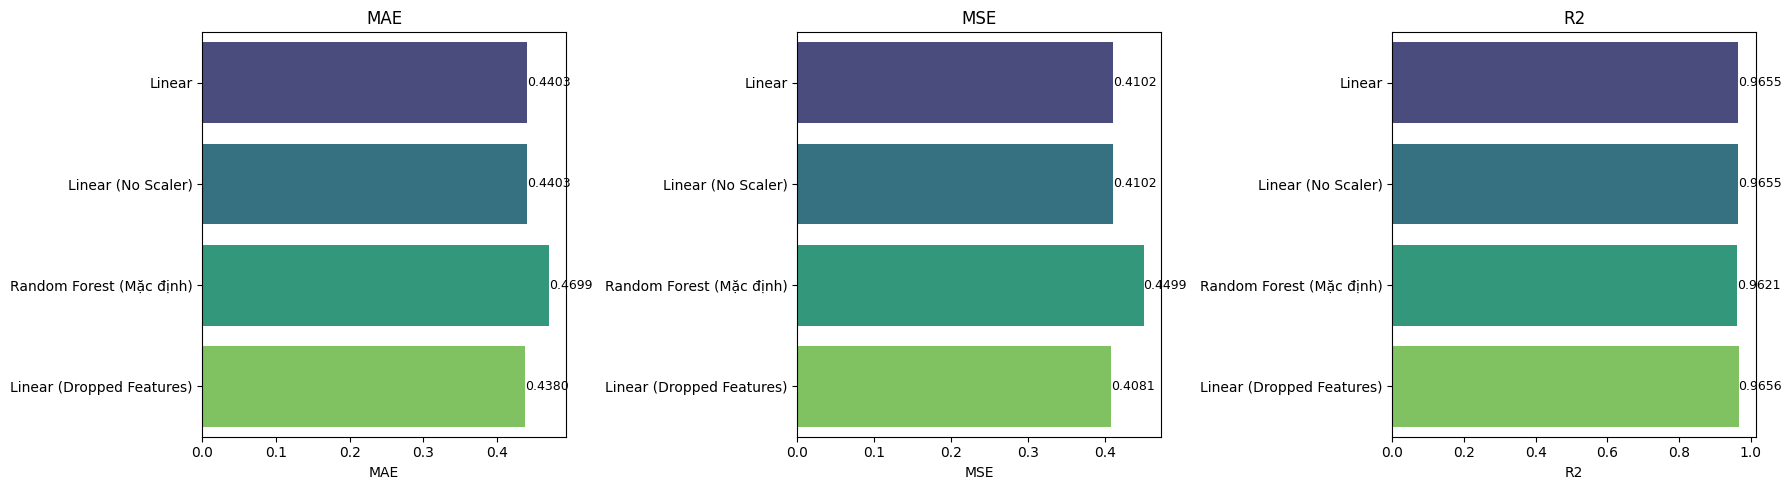

In [30]:
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_linear_no_scaler = Pipeline([
    ('regressor', LinearRegression())
])

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42))
])


pipe_linear_dropped = Pipeline([
    ('selector', feature_remover),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])


models = {
    "Linear": pipe_linear,
    "Linear (No Scaler)": pipe_linear_no_scaler,
    "Random Forest (Mặc định)": pipe_rf,
    "Linear (Dropped Features)": pipe_linear_dropped
}
results = {}


for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

df_results = pd.DataFrame(results).T
print("=== BẢNG SO SÁNH CÁC MÔ HÌNH BAN ĐẦU ===")
display(df_results)

import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(metrics):
    sns.barplot(x=df_results[metric].values, y=df_results.index, ax=axes[i], palette='viridis')
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('')
    for j, v in enumerate(df_results[metric].values):
        axes[i].text(v, j, f"{v:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
params = {
    "rf__n_estimators": [100, 200, 300],
    "rf__criterion": ["squared_error"],
    "rf__max_depth": [10, 15, 20, None],
}


tscv = TimeSeriesSplit(n_splits=4)

grid_search = GridSearchCV(
    estimator=pipe_rf,
    param_grid=params,
    cv=tscv,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

print("--- BẮT ĐẦU QUÁ TRÌNH TÌM THAM SỐ TỐI ƯU ---")
grid_search.fit(x_train, y_train)

--- BẮT ĐẦU QUÁ TRÌNH TÌM THAM SỐ TỐI ƯU ---
Fitting 4 folds for each of 12 candidates, totalling 48 fits
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=100; total time=   4.7s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=100; total time=   8.1s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=200; total time=   9.8s
[CV] END rf__criterion=squared_error, rf__max_depth=15, rf__n_estimators=100; total time=   6.0s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=100; total time=  13.2s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=300; total time=  14.2s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=100; total time=  16.9s
[CV] END rf__criterion=squared_error, rf__max_depth=10, rf__n_estimators=200; total time=  17.0s
[CV] END rf__criterion=squared_error, rf__max_depth=15, rf__n_estimators=100; total time=  11.6s
[CV] END rf__criterio

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__criterion': ['squared_error'], 'rf__max_depth': [10, 15, ...], 'rf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

=== KẾT QUẢ RANDOM FOREST SAU TINH CHỈNH ===
Bộ tham số tối ưu nhất tìm được: {'rf__criterion': 'squared_error', 'rf__max_depth': 10, 'rf__n_estimators': 100}



,metric,value
0,MAE,0.464360
1,MSE,0.444250
2,R2,0.962585


/tmp/ipykernel_206308/2665669831.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='metric', y='value', data=metrics_df, palette='magma', ax=ax)


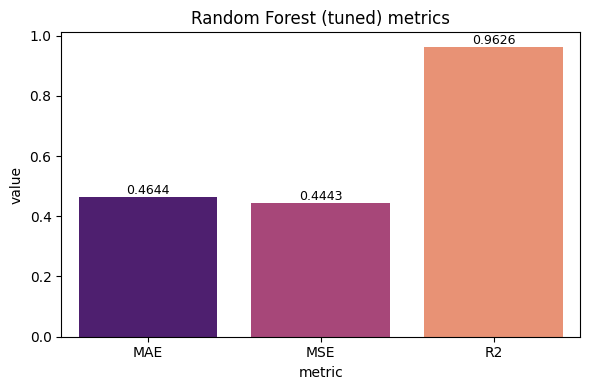

In [31]:
# Lấy mô hình có tham số tốt nhất để dự báo trên tập Test
best_pipe_rf = grid_search.best_estimator_
y_predicted = best_pipe_rf.predict(x_test)

# Tính các chỉ số và trực quan hoá kết quả thay vì chỉ in
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print("=== KẾT QUẢ RANDOM FOREST SAU TINH CHỈNH ===")
print(f"Bộ tham số tối ưu nhất tìm được: {grid_search.best_params_}\n")
metrics_df = pd.DataFrame({'metric': ['MAE', 'MSE', 'R2'], 'value': [mae, mse, r2]})
display(metrics_df)

import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x='metric', y='value', data=metrics_df, palette='magma', ax=ax)
ax.set_title('Random Forest (tuned) metrics')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

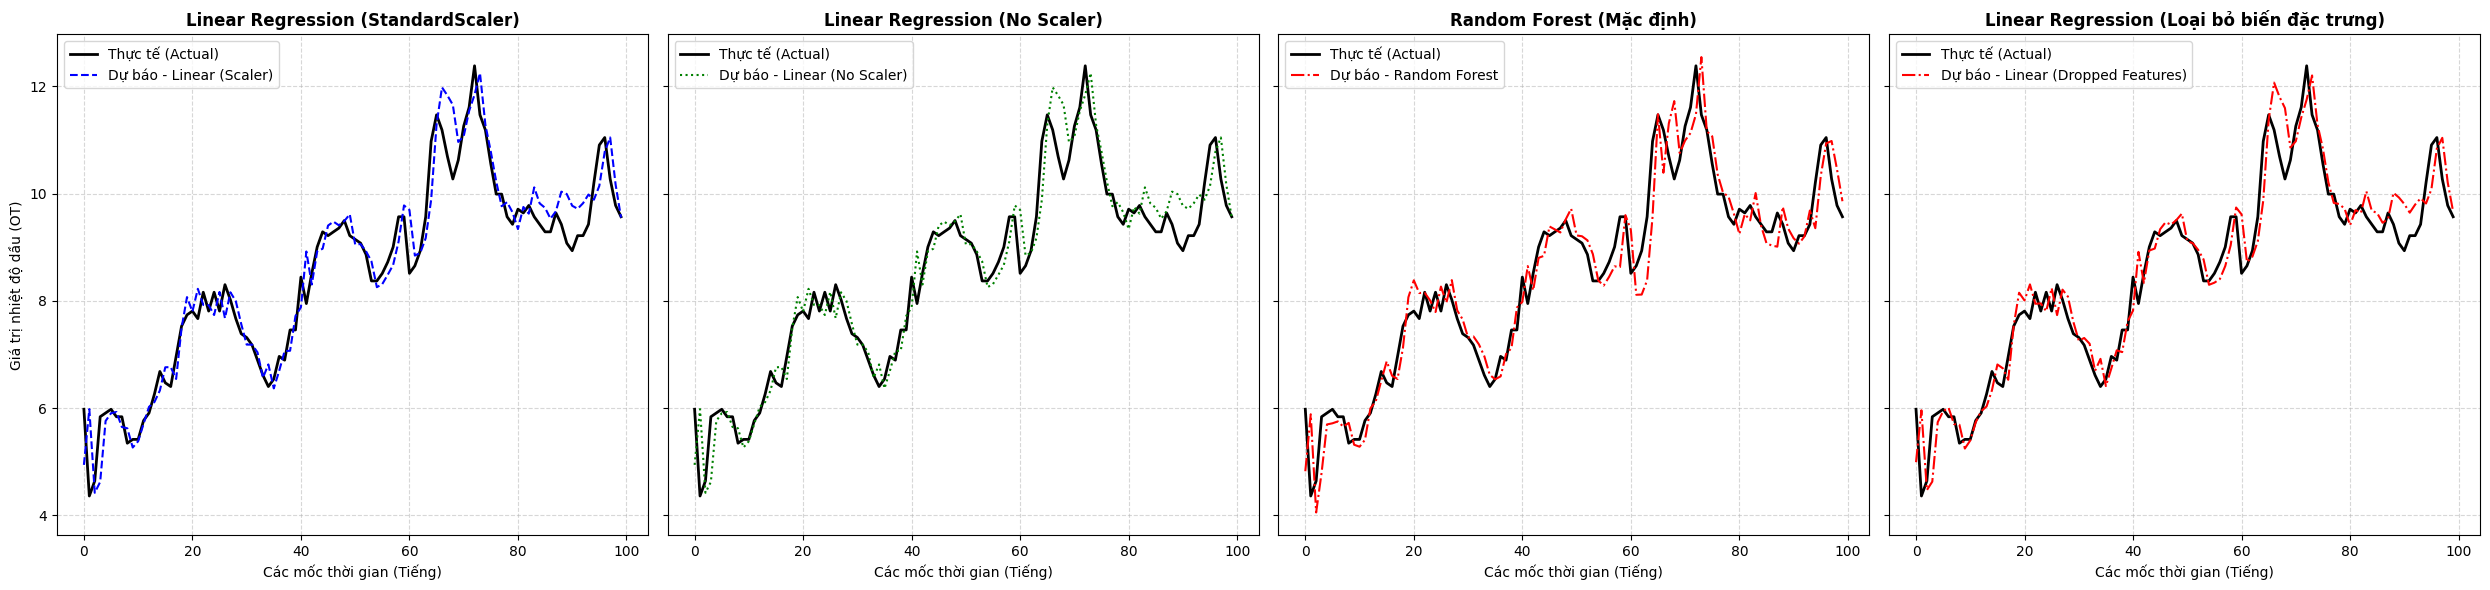

In [26]:
# 1. Dự báo kết quả của cả 3 mô hình ban đầu trên tập Test
pred_linear = pipe_linear.predict(x_test)
pred_linear_no_scaler = pipe_linear_no_scaler.predict(x_test)
pred_rf = pipe_rf.predict(x_test)
pred_linear_dropped = pipe_linear_dropped.predict(x_test)

# 2. Cấu hình số lượng điểm dữ liệu cuối muốn vẽ (Ví dụ: 100 điểm cuối)
zoom_steps = 100
time_axis = np.arange(zoom_steps)

# Lấy dữ liệu thực tế của 100 điểm cuối
actual_data = y_test.iloc[-zoom_steps:].values

# 3. Khởi tạo khung tranh gồm 1 hàng và 4 cột hình nằm ngang
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(25, 6), sharey=True)

# -------------------------------------------------------------------------
# HÌNH 1: SO SÁNH LINEAR REGRESSION (CÓ SCALER)
# -------------------------------------------------------------------------
axes[0].plot(time_axis, actual_data, label='Thực tế (Actual)',
             color='black', linewidth=2)
axes[0].plot(time_axis, pred_linear[-zoom_steps:],
             label='Dự báo - Linear (Scaler)', color='blue', linewidth=1.5, linestyle='--')
axes[0].set_title("Linear Regression (StandardScaler)",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Các mốc thời gian (Tiếng)")
axes[0].set_ylabel("Giá trị nhiệt độ dầu (OT)")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# -------------------------------------------------------------------------
# HÌNH 2: SO SÁNH LINEAR REGRESSION (KHÔNG SCALER)
# -------------------------------------------------------------------------
axes[1].plot(time_axis, actual_data, label='Thực tế (Actual)',
             color='black', linewidth=2)
axes[1].plot(time_axis, pred_linear_no_scaler[-zoom_steps:],
             label='Dự báo - Linear (No Scaler)', color='green', linewidth=1.5, linestyle=':')
axes[1].set_title("Linear Regression (No Scaler)",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Các mốc thời gian (Tiếng)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left')

# -------------------------------------------------------------------------
# HÌNH 3: SO SÁNH RANDOM FOREST
# -------------------------------------------------------------------------
axes[2].plot(time_axis, actual_data, label='Thực tế (Actual)',
             color='black', linewidth=2)
axes[2].plot(time_axis, pred_rf[-zoom_steps:], label='Dự báo - Random Forest',
             color='red', linewidth=1.5, linestyle='-.')
axes[2].set_title("Random Forest (Mặc định)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Các mốc thời gian (Tiếng)")
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left')

# -------------------------------------------------------------------------
# HÌNH 4: SO SÁNH LINEAR REGRESSION (LOẠI BỎ BIẾN ĐẶC TRƯNG)
# -------------------------------------------------------------------------
axes[3].plot(time_axis, actual_data, label='Thực tế (Actual)',
             color='black', linewidth=2)
axes[3].plot(time_axis, pred_linear_dropped[-zoom_steps:], label='Dự báo - Linear (Dropped Features)',
             color='red', linewidth=1.5, linestyle='-.')
axes[3].set_title("Linear Regression (Loại bỏ biến đặc trưng)", fontsize=12, fontweight='bold')
axes[3].set_xlabel("Các mốc thời gian (Tiếng)")
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='upper left')

# 4. Tối ưu khoảng cách giữa các đồ thị để không bị đè chữ
plt.tight_layout()

# 5. Hiển thị đồ thị ra Notebook
plt.show()